In [18]:
import numpy as np
import matplotlib.pyplot as plt
import os

FIG_DIR = "figures_periodic_chain"
os.makedirs(FIG_DIR, exist_ok=True)

KS = np.linspace(0, 2*np.pi, 8192, endpoint=False) # k-grid for continuum integrals (periodic grid; endpoint=False to exclude 2pi)

# ============================================================
# SSH: basic functions
# ============================================================

def ssh_couplings(lam: float) -> tuple[float, float]:
    """t1 = 1 - lam,  t2 = 1 + lam"""
    return 1.0 - lam, 1.0 + lam

def ssh_dispersion_from_t1t2(k: np.ndarray, t1, t2) -> np.ndarray:
    """|h(k)| = sqrt(t1^2 + t2^2 + 2 t1 t2 cos k)"""
    return np.sqrt(t1**2 + t2**2 + 2.0*t1*t2*np.cos(k))

def ssh_energy_pm(k: np.ndarray, lam: float) -> tuple[np.ndarray, np.ndarray]:
    """E_-(k), E_+(k) using lam parametrization."""
    t1, t2 = ssh_couplings(lam)
    Ep = ssh_dispersion_from_t1t2(k, t1, t2)
    return -Ep, Ep

def fermi_dirac(E: np.ndarray, beta: float) -> np.ndarray:
    """Fermi–Dirac distribution: n(E) = 1/(exp(beta E)+1)."""
    return 1.0 / (np.exp(beta * E) + 1.0)

def k_grid_finiteN(N: int, bz: str = "0_2pi") -> np.ndarray:
    """
    Discrete k grid for a periodic chain of length N:
      k_n = 2π n / N , n=0,...,N-1

    bz="0_2pi" -> [0,2π)
    bz="pm_pi" -> [-π,π)
    """
    if bz == "0_2pi":
        return np.linspace(0.0, 2.0*np.pi, N, endpoint=False)
    elif bz == "pm_pi":
        return np.linspace(-np.pi, np.pi, N, endpoint=False)
    else:
        raise ValueError("bz must be '0_2pi' or 'pm_pi'")
    
def h_complex_from_lam(lam: float, k: np.ndarray) -> np.ndarray:
    """
    Bloch off-diagonal term: h(k) = t1 + t2 e^{-ik}.
    Uses our convention t1=1-lam, t2=1+lam (via ssh_couplings).
    """
    t1, t2 = ssh_couplings(lam)
    return t1 + t2 * np.exp(-1j * k)

def abs_h_from_lam(lam: float, k: np.ndarray) -> np.ndarray:
    return np.abs(h_complex_from_lam(lam, k))

def phi_k_from_lam(lam: float, k: np.ndarray) -> np.ndarray:
    # phase in (-0, 2pi]
    return np.angle(h_complex_from_lam(lam, k))

def eta_continuum(lam: float, beta=np.inf, r: int = 0, ks: np.ndarray = KS) -> float:
    """
    Continuum correlator amplitude:
      η_r(λ,β) = (1/2π) ∫ dk  tanh(β|h(k)|/2) cos(rk + φ(k))
        where r=m-n is the site separation, and φ(k) = arg(h(k)).
    beta = np.inf -> tanh(...) -> 1 (ground-state limit)
    """
    ph = phi_k_from_lam(lam, ks)
    if np.isinf(beta):
        w = 1.0
        return np.cos(r*ks + ph).mean()
    else:
        w = np.tanh(0.5 * beta * abs_h_from_lam(lam, ks))
        return (w * np.cos(r*ks + ph)).mean()

def eta_finiteN(lam: float, N: int, beta=np.inf, r: int = 0, bz: str = "0_2pi") -> float:
    """
    Finite-N correlator amplitude:
      η_r(λ,β;N) = (1/N) Σ_k  tanh(β|h(k)|/2) cos(rk + φ(k))

    beta=np.inf -> tanh -> 1 (T=0 limit)
    """
    ks = k_grid_finiteN(N, bz=bz)
    ph = phi_k_from_lam(lam, ks)

    if np.isinf(beta):
        return np.cos(r*ks + ph).mean()
    else:
        w = np.tanh(0.5 * beta * abs_h_from_lam(lam, ks))
        return (w * np.cos(r*ks + ph)).mean()
    
def concurrence_from_eta(eta: float) -> float:
    """
    For the X-state structure used in the report:
      C = max(0, 1/2 (eta^2 + 2|eta| - 1))
    This matches the Kim&Cho active branch at T=0 (eta>=0),
    and stays safe if eta changes sign.
    """
    return max(0.0, 0.5 * (eta**2 + 2.0*np.abs(eta) - 1.0))

def _crossing_at_boundary(x: np.ndarray, y: np.ndarray, j: int, eps: float):
    """
    Linear interpolation for crossing y=eps between indices j-1 and j.
    Assumes y[j-1] and y[j] are on different sides of eps.
    """
    x0, x1 = x[j-1], x[j]
    y0, y1 = y[j-1], y[j]
    if np.isclose(y1, y0):
        return x1
    return x0 + (eps - y0) * (x1 - x0) / (y1 - y0)

def nonzero_region_boundaries(
    x: np.ndarray, y: np.ndarray, eps: float = 1e-10
):
    """
    Finds the left and right boundary of the region where y > eps.
    Returns (x_left, x_right). If y never exceeds eps -> (None, None).

    Works for:
      - "turn-on" (0 -> >0) on the right side
      - "turn-off" (>0 -> 0) on the right side
      - any single contiguous nonzero region (which is our case)
    """
    mask = y > eps
    if not np.any(mask):
        return None, None

    idx = np.where(mask)[0]
    i_left = idx[0]
    i_right = idx[-1]

    # left boundary
    if i_left == 0:
        x_left = x[0]
    else:
        x_left = _crossing_at_boundary(x, y, i_left, eps)

    # right boundary
    if i_right == len(x) - 1:
        x_right = x[-1]
    else:
        x_right = _crossing_at_boundary(x, y, i_right + 1, eps)

    return x_left, x_right

def lambda_critical_for_beta(beta, lams, r, ks=KS, eps=1e-10):
    """
    For fixed beta, scan lambda grid and return the critical lambda boundary.
    r=0 -> C1: take RIGHT boundary (where C1 -> 0)
    r=1 -> C2: take LEFT boundary  (where C2 turns on)
    """
    eta = np.array([eta_continuum(l, beta=beta, r=r, ks=ks) for l in lams])
    C   = np.array([concurrence_from_eta(x) for x in eta])
    left, right = nonzero_region_boundaries(lams, C, eps=eps)
    return right if r == 0 else left

def bell_from_eta(eta: float) -> float:
    """<B> = 2*sqrt(2)*|eta|  (CHSH Bell operator expectation in your notation)"""
    return 2.0 * np.sqrt(2.0) * np.abs(eta)

def bell_continuum(lam: float, beta=np.inf, r: int = 0, ks: np.ndarray = KS) -> float:
    """Compute <B>(lambda,beta) using eta_continuum."""
    eta = eta_continuum(lam, beta=beta, r=r, ks=ks)
    return bell_from_eta(eta)

def lambda_critical_bell_for_beta(beta, lams, r, ks=KS, eps=1e-10):
    """
    Return critical lambda where <B>(lambda,beta,r)=2 (CHSH threshold).
    We detect violation region via y = <B>-2 > eps and use your existing boundary finder.

    Convention:
      r=0 -> take RIGHT boundary
      r=1 -> take LEFT boundary
    """
    B = np.array([bell_continuum(l, beta=beta, r=r, ks=ks) for l in lams])
    y = B - 2.0
    left, right = nonzero_region_boundaries(lams, y, eps=eps)
    return right if r == 0 else left
# ============================================================
# SSH: plotting functions
# ============================================================

def make_figure_ssh_bands(
    lams_line=(-0.8, -0.4, 0.0, 0.4, 0.8),
    lam_range=(-1.0, 1.0),
    nk=200,
    nlam=200,
    cmap="inferno",
    savepath=None,
    show=True,
):
    if savepath is None:
        savepath = f"{FIG_DIR}/fig_1_ssh_bands.pdf"

    k = np.linspace(0.0, 2.0*np.pi, nk)
    lam_grid = np.linspace(lam_range[0], lam_range[1], nlam)
    K, L = np.meshgrid(k, lam_grid)

    t1 = 1.0 - L
    t2 = 1.0 + L
    E2D = ssh_dispersion_from_t1t2(K, t1, t2)

    fig, axes = plt.subplots(2, 1, figsize=(8, 10), constrained_layout=True)

    # Panel A
    ax1 = axes[0]
    for lam in lams_line:
        Em, Ep = ssh_energy_pm(k, lam)
        (line,) = ax1.plot(k, Ep, label=rf"$\lambda={lam}$")
        ax1.plot(k, Em, color=line.get_color())

    ax1.set_xlabel(r"$k$")
    ax1.set_ylabel("Energy")
    ax1.set_title(r"SSH band structure for different $\lambda$")
    ax1.legend()

    xticks = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])

    # Panel B
    ax2 = axes[1]
    pcm = ax2.pcolormesh(K, L, E2D, shading="auto", cmap=cmap)
    ax2.set_xlabel(r"$k$")
    ax2.set_ylabel(r"$\lambda$")
    ax2.set_title(r"Upper SSH energy band $E_+(k,\lambda)$")
    ax2.set_xticks(xticks)
    ax2.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
    fig.colorbar(pcm, ax=ax2, label="Energy")

    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, axes

def make_figure_upper_occupation_overlay(
    lam: float = 0.0,
    betas=(30, 5, 2, 1, 0.5),
    nk: int = 400,
    savepath: str | None = None,
    show: bool = True,
):
    """
    Single-panel overlay of n_+(k) for multiple betas at fixed lambda.
    Uses n_+(k) = 1/(exp(beta E_+(k))+1), with E_+(k)=|h(k)|.
    """
    if savepath is None:
        savepath = f"{FIG_DIR}/fig_2_occ_overlay_lam{lam}.pdf"

    k = np.linspace(0.0, 2.0*np.pi, nk, endpoint=False)

    t1, t2 = ssh_couplings(lam)
    E_plus = ssh_dispersion_from_t1t2(k, t1, t2)

    fig, ax = plt.subplots(1, 1, figsize=(6.5, 3.8))

    for beta in betas:
        n_plus = fermi_dirac(E_plus, beta)
        ax.plot(k, n_plus, label=rf"$\beta={beta}$")

    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$n_+(k)$")
    ax.set_title(rf"Upper band occupation $n_+(k)$ (fixed $\lambda={lam}$)")

    ax.set_xticks([0, np.pi, 2*np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi$", r"$2\pi$"])
    ax.set_ylim(-0.02, 0.52)  # çünkü n_+ ∈ [0, 1/2] (mu=0 simetri)

    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()

    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

def make_figure_upper_occupation_overlay_lams(
    beta: float = 2.0,
    lams=(0.0, 0.1, 0.4, 0.8),
    nk: int = 400,
    savepath: str | None = None,
    show: bool = True,
):
    if savepath is None:
        savepath = f"{FIG_DIR}/fig_3_occ_overlay_beta{beta}.pdf"

    k = np.linspace(0.0, 2.0*np.pi, nk, endpoint=False)

    fig, ax = plt.subplots(1, 1, figsize=(6.5, 3.8))

    for lam in lams:
        t1, t2 = ssh_couplings(lam)
        E_plus = ssh_dispersion_from_t1t2(k, t1, t2)
        n_plus = fermi_dirac(E_plus, beta)
        ax.plot(k, n_plus, label=rf"$\lambda={lam}$")

    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$n_+(k)$")
    ax.set_title(rf"Upper band occupation $n_+(k)$ (fixed $\beta={beta}$)")

    ax.set_xticks([0, np.pi, 2*np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi$", r"$2\pi$"])
    ax.set_ylim(-0.02, 0.52)

    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()

    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

def make_figure_concurrence_vs_lambda(
    lam_min=-1.0,
    lam_max=1.0,
    num=2001,
    beta=np.inf,
    ks=KS,
    savepath=None,
    show=True,
    title=None,
    mark_lambda0=True,
):
    """
    Kim & Cho Fig.2 style plot of concurrence vs lambda, with:
      - C1(λ)  (r=0)
      - C2(λ)  (r=1)
      - dC2/dλ (right axis)
    beta=np.inf -> ground-state limit
    beta finite  -> thermal
    """

    if savepath is None:
        tag = "T0" if np.isinf(beta) else f"beta{beta:g}"
        savepath = f"{FIG_DIR}/fig_4_concurrence_{tag}.pdf"

    lams = np.linspace(lam_min, lam_max, num)

    # compute eta and concurrence
    eta0 = np.array([eta_continuum(l, beta=beta, r=0, ks=ks) for l in lams])
    eta1 = np.array([eta_continuum(l, beta=beta, r=1, ks=ks) for l in lams])

    C1 = np.array([concurrence_from_eta(x) for x in eta0])
    C2 = np.array([concurrence_from_eta(x) for x in eta1])

    # derivative (clean + robust)
    dC2 = np.gradient(C2, lams)

    # ---- plot
    fig, axC = plt.subplots(figsize=(7.2, 4.6))
    axD = axC.twinx()

    ln1, = axC.plot(lams, C1, color="mediumorchid", lw=2, label=r"$C_1(\lambda)$")
    ln2, = axC.plot(lams, C2, color="seagreen",    lw=2, label=r"$C_2(\lambda)$")
    ln3, = axD.plot(lams, dC2, color="deepskyblue", lw=2, label=r"$\partial_\lambda C_2$")

    if mark_lambda0:
        axC.axvline(0.0, ls="--", lw=1)

    axC.set_xlabel(r"$\lambda$")
    axC.set_ylabel("Concurrence")
    axD.set_ylabel(r"$\partial_\lambda C_2$")

    tag = "T=0" if np.isinf(beta) else rf"$\beta={beta:g}$"
    axC.set_title(title or rf"Wootters concurrence ({tag})")

    # combined legend
    lines = [ln1, ln2, ln3]
    axC.legend(lines, [l.get_label() for l in lines], frameon=False, loc="upper left")

    plt.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    eps = 1e-10  

    c1_left, c1_right = nonzero_region_boundaries(lams, C1, eps=eps)
    c2_left, c2_right = nonzero_region_boundaries(lams, C2, eps=eps)

    # critical lambda values:
    lamc1 = c1_right
    lamc2 = c2_left
    print(f"[{tag}] lambda_c1 (C1 -> 0) ~ {lamc1}")
    print(f"[{tag}] lambda_c2 (C2 turns on) ~ {lamc2}")

    if lamc1 is not None:
        axC.axvline(lamc1, ls="--", color="gray", lw=1)
    if lamc2 is not None:
        axC.axvline(lamc2, ls="--", color="gray", lw=1)

    return fig, (axC, axD)

def make_figure_C1_overlay_betas(
    betas=(np.inf, 30, 10, 5, 2, 1),
    lam_min=-1.0,
    lam_max=1.0,
    num=800,
    ks=KS,
    eps=1e-10,
    savepath=None,
    show=True,
    title=None,
):
    """
    Overlay plot of C1(λ) for multiple beta values on a single axis.
    Includes printed critical lambda where C1 drops to ~0 (right boundary).
    """
    if savepath is None:
        savepath = f"{FIG_DIR}/fig_5_C1_overlay_betas.pdf"

    lams = np.linspace(lam_min, lam_max, num)

    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    for beta in betas:
        eta0 = np.array([eta_continuum(l, beta=beta, r=0, ks=ks) for l in lams])
        C1 = np.array([concurrence_from_eta(x) for x in eta0])

        # critical lambda (where C1 goes to ~0): use nonzero region right boundary
        c1_left, c1_right = nonzero_region_boundaries(lams, C1, eps=eps)
        tag = "∞" if np.isinf(beta) else f"{beta:g}"
        print(f"[C1 overlay] beta={tag:>3}  lambda_c1 (C1->0) ~ {c1_right}")

        ax.plot(lams, C1, lw=2, label=rf"$\beta={tag}$")

    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$C_1(\lambda)$")
    ax.set_xlim(lam_min, lam_max)

    ax.set_title(title or r"$C_1(\lambda)$ for different temperatures")
    ax.legend(frameon=False, ncol=2)

    plt.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

def make_figure_concurrence_finiteN(
    lam_lo=-0.05,
    lam_hi=0.05,
    num=1201,
    Ns=(50, 51),
    beta=np.inf,
    r=1,
    bz="0_2pi",
    savepath=None,
    show=True,
    title=None,
):
    """
    Plot C_r(λ) for several finite N values.
    r=0 -> C1-like, r=1 -> C2-like (depending on your mapping).
    """
    if savepath is None:
        tag = "T0" if np.isinf(beta) else f"beta{beta:g}"
        savepath = f"{FIG_DIR}/fig_6_finiteN_Cr_r{r}_{tag}.pdf"

    lams = np.linspace(lam_lo, lam_hi, num)
    fig, ax = plt.subplots(figsize=(7.0, 4.2))

    for N in Ns:
        eta = np.array([eta_finiteN(l, N=N, beta=beta, r=r, bz=bz) for l in lams])
        C = np.array([concurrence_from_eta(x) for x in eta])
        tagN = "T=0" if np.isinf(beta) else rf"$\beta={beta:g}$"
        ax.plot(lams, C, lw=2, label=rf"$N={N}$ ({tagN})")

    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(rf"$C_{r}(\lambda)$")
    ax.set_title(title or "Finite-$N$ concurrence")
    ax.legend(frameon=False)

    plt.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

def make_figure_lambda_critical_vs_beta(
    betas=None,
    lam_min=-1,
    lam_max=1,
    nlam=600,
    eps=1e-10,
    ks=KS,
    savepath=None,
    show=True,
    print_values=True,
    save_csv_path=None,   # e.g. f"{FIG_DIR}/lambda_critical_vs_beta.csv"
):
    if betas is None:
        betas = np.r_[np.geomspace(0.2, 30.0, 100), np.inf]

    lams = np.linspace(lam_min, lam_max, nlam)

    lamc1 = []
    lamc2 = []
    for beta in betas:
        lamc1.append(lambda_critical_for_beta(beta, lams, r=0, ks=ks, eps=eps))
        lamc2.append(lambda_critical_for_beta(beta, lams, r=1, ks=ks, eps=eps))

    lamc1 = np.array(lamc1, dtype=float)
    lamc2 = np.array(lamc2, dtype=float)

    # ---- PRINT TABLE (NEW)
    if print_values:
        print("\nCritical lambdas from concurrence boundary detection")
        print(f"eps = {eps:g}, ks = {ks}, lambda-grid = [{lam_min}, {lam_max}] with nlam={nlam}")
        print("--------------------------------------------------------------")
        print(f"{'beta':>10}   {'lambda_c1 (C1->0)':>18}   {'lambda_c2 (C2 on)':>18}")
        for b, c1, c2 in zip(betas, lamc1, lamc2):
            bstr = "inf" if np.isinf(b) else f"{b:10.6g}"
            c1str = "None" if np.isnan(c1) else f"{c1:18.10f}"
            c2str = "None" if np.isnan(c2) else f"{c2:18.10f}"
            print(f"{bstr:>10}   {c1str}   {c2str}")

    # ---- SAVE CSV (NEW)
    if save_csv_path is not None:
        beta_out = np.array(betas, dtype=float)
        header = "beta,lambda_c1,lambda_c2"
        data = np.column_stack([beta_out, lamc1, lamc2])
        np.savetxt(save_csv_path, data, delimiter=",", header=header, comments="")
        if print_values:
            print("\nSaved CSV to:", save_csv_path)

    # x-axis: finite betas for log plot
    finite = np.isfinite(betas)
    betas_f = np.array(betas)[finite]
    lamc1_f = lamc1[finite]
    lamc2_f = lamc2[finite]

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(betas_f, lamc1_f, lw=2, label=r"$\lambda_{c1}(\beta)$  (C1$\to$0)")
    ax.plot(betas_f, lamc2_f, lw=2, label=r"$\lambda_{c2}(\beta)$  (C2 turns on)")


    ax.set_xscale("log")
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$\lambda_c$")
    ax.set_title(r"Critical $\lambda_c(\beta)$ from concurrence")
    ax.legend(frameon=False)

    plt.tight_layout()
    if savepath is not None:
        savepath = f"{FIG_DIR}/fig_7_lambda_critical_vs_beta.pdf"
        fig.savefig(savepath, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax, (betas, lamc1, lamc2)

def make_figure_bell_vs_lambda(
    lam_min=-1.0,
    lam_max=1.0,
    num=400,
    betas=np.inf,   # <-- artık liste olabilir
    r_values=(0, 1),
    ks=KS,
    savepath=None,
    show=True,
    title=None,
    mark_lambda0=True,
):
    """
    Plot <B>(lambda) for one or multiple beta values.

    Parameters
    ----------
    betas : float or list of float
        e.g.
        betas = np.inf
        betas = [0.5, 1, 2, 5, np.inf]

    r_values : tuple
        e.g. (0,), (1,), or (0,1)
    """

    # tek değer verilirse listeye çevir
    if np.isscalar(betas):
        betas = [betas]

    if savepath is None:
        savepath = f"{FIG_DIR}/fig_8_bell_vs_lambda_multi_beta.pdf"

    lams = np.linspace(lam_min, lam_max, num)

    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    for beta in betas:

        beta_label = "∞" if np.isinf(beta) else f"{beta:g}"

        for r in r_values:

            B_vals = np.array([
                bell_continuum(l, beta=beta, r=r, ks=ks)
                for l in lams
            ])

            ax.plot(
                lams,
                B_vals,
                lw=2,
                label=rf"$\langle B\rangle$  ($r={r}$, $\beta={beta_label}$)"
            )

    # CHSH bound
    ax.axhline(2.0, ls="--", lw=1, color="black", label=r"CHSH bound (=2)")

    if mark_lambda0:
        ax.axvline(0.0, ls="--", lw=1)

    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(r"$\langle B\rangle$")
    ax.set_xlim(lam_min, lam_max)

    if title is None:
        title = r"Bell expectation $\langle B\rangle$ vs $\lambda$"

    ax.set_title(title)

    ax.legend(frameon=False, fontsize=9)

    plt.tight_layout()
    fig.savefig(savepath, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax

def make_figure_lambda_critical_bell_vs_beta(
    betas,
    lam_min=-1.0,
    lam_max=1.0,
    nlam=600,
    eps=1e-10,
    ks=KS,
    savepath=None,
    show=True,
    title=None,
    save_csv_path=None,   # <-- NEW
):
    """
    Plot lambda_critical(beta) extracted from <B>=2 threshold,
    for r=0 and r=1.

    If save_csv_path is provided, saves:
        beta, lambda_B_r0, lambda_B_r1
    """

    lams = np.linspace(lam_min, lam_max, nlam)

    lamB0 = []
    lamB1 = []

    for beta in betas:
        lamB0.append(lambda_critical_bell_for_beta(beta, lams, r=0, ks=ks, eps=eps))
        lamB1.append(lambda_critical_bell_for_beta(beta, lams, r=1, ks=ks, eps=eps))

    lamB0 = np.array(lamB0, dtype=float)
    lamB1 = np.array(lamB1, dtype=float)

    betas = np.array(betas, dtype=float)
    finite = np.isfinite(betas)

    # ---------------------------
    # SAVE CSV (NEW PART)
    # ---------------------------
    if save_csv_path is not None:
        data = np.column_stack([betas, lamB0, lamB1])
        header = "beta,lambda_B_r0,lambda_B_r1"
        np.savetxt(save_csv_path, data, delimiter=",",
                   header=header, comments="")
        print("Saved Bell critical data to:", save_csv_path)

    # ---------------------------
    # Plot
    # ---------------------------
    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    ax.plot(betas[finite], lamB0[finite],
            lw=2, label=r"$\lambda^{(B)}_{\mathrm{crit}}(\beta)$  ($r=0$)")
    ax.plot(betas[finite], lamB1[finite],
            lw=2, label=r"$\lambda^{(B)}_{\mathrm{crit}}(\beta)$  ($r=1$)")

    ax.set_xscale("log")
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$\lambda^{(B)}_{\mathrm{crit}}$")
    ax.set_title(title or r"Critical line from Bell threshold $\langle B\rangle=2$")
    ax.legend(frameon=False)

    plt.tight_layout()

    if savepath is None:
        savepath = f"{FIG_DIR}/fig_9_lambda_critical_bell_vs_beta.pdf"
    fig.savefig(savepath, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax, (betas, lamB0, lamB1)

def plot_entanglement_phase_diagram(
    csv_conc_path,
    csv_bell_path,
    lam_min=-1.0,
    lam_max=1.0,
    out_pdf_path=None,
    show=True,
):
    """
    Entanglement phase diagram using:

      - lambda_c1(beta)  : concurrence boundary (C1 -> 0)
      - lambda_B(beta)   : Bell boundary (<B> -> 2)

    Regions:
      1) lambda < lambda_B      : Bell-violating (blue)
      2) lambda_B < lambda < lc1: entangled but local (yellow)
      3) lambda > lc1           : separable (light grey)
    """

    # --- load concurrence CSV
    conc = np.genfromtxt(csv_conc_path, delimiter=",", names=True)
    beta_c = conc["beta"].astype(float)
    lam_c1 = conc["lambda_c1"].astype(float)

    mc = np.isfinite(beta_c) & np.isfinite(lam_c1)
    beta_c, lam_c1 = beta_c[mc], lam_c1[mc]
    oc = np.argsort(beta_c)
    beta_c, lam_c1 = beta_c[oc], lam_c1[oc]

    # --- load Bell CSV
    bell = np.genfromtxt(csv_bell_path, delimiter=",", names=True)
    beta_b = bell["beta"].astype(float)
    lam_B0 = bell["lambda_B_r0"].astype(float)

    mb = np.isfinite(beta_b) & np.isfinite(lam_B0)
    beta_b, lam_B0 = beta_b[mb], lam_B0[mb]
    ob = np.argsort(beta_b)
    beta_b, lam_B0 = beta_b[ob], lam_B0[ob]

    # --- match beta grid (common betas only)
    beta_common = np.intersect1d(beta_c, beta_b)

    # align arrays
    lam_c1_interp = np.interp(beta_common, beta_c, lam_c1)
    lam_B_interp  = np.interp(beta_common, beta_b, lam_B0)

    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    # --- region fills (x = beta, y = lambda)
    ax.fill_between(beta_common, lam_min, lam_B_interp,
                    color="lightblue", alpha=0.6)

    ax.fill_between(beta_common, lam_B_interp, lam_c1_interp,
                    color="khaki", alpha=0.7)

    ax.fill_between(beta_common, lam_c1_interp, lam_max,
                    color="lightgrey", alpha=0.5)

    # --- critical curves
    ax.plot(beta_common, lam_c1_interp,
            color="red", lw=2,
            label=r"$\lambda_{c1}(\beta)$ (C1$\to$0)")

    ax.plot(beta_common, lam_B_interp,
            color="blue", lw=2,
            label=r"$\lambda_{B}(\beta)$ ($\langle B\rangle\to2$)")

    ax.set_xscale("log")
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$\lambda$")
    ax.set_ylim(lam_min, lam_max)
    ax.set_xlim(beta_common.min(), beta_common.max())

    ax.set_title(r"Entanglement Phase Diagram ($r=0$)")
    ax.legend(frameon=False)

    plt.tight_layout()

    if out_pdf_path is not None:
        os.makedirs(os.path.dirname(out_pdf_path), exist_ok=True)
        fig.savefig(out_pdf_path, bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax

In [8]:
betas = np.unique(np.sort(np.r_[
    np.geomspace(0.2, 30.0, 120),
    np.geomspace(0.75, 1.3, 180),
    0.44766611032525605,
    0.9106328601027525
]))


Critical lambdas from concurrence boundary detection
eps = 1e-10, ks = [0.00000000e+00 7.66990394e-04 1.53398079e-03 ... 6.28088434e+00
 6.28165133e+00 6.28241832e+00], lambda-grid = [-1, 1] with nlam=600
--------------------------------------------------------------
      beta    lambda_c1 (C1->0)    lambda_c2 (C2 on)
       0.2   None   None
  0.208601   None   None
  0.217572   None   None
  0.226929   None   None
  0.236688   None   None
  0.246867   None   None
  0.257483   None   None
  0.268556   None   None
  0.280106   None   None
  0.292152   None   None
  0.304716   None   None
   0.31782   None   None
  0.331488   None   None
  0.345744   None   None
  0.360612   None   None
  0.376121   None   None
  0.392296   None   None
  0.409167   None   None
  0.426763   None   None
  0.445116        -0.9799666114         0.9799666114
  0.447666        -0.9666110196         0.9666110196
  0.464258        -0.8964941586         0.8964941586
  0.484224        -0.8196995008         0.81

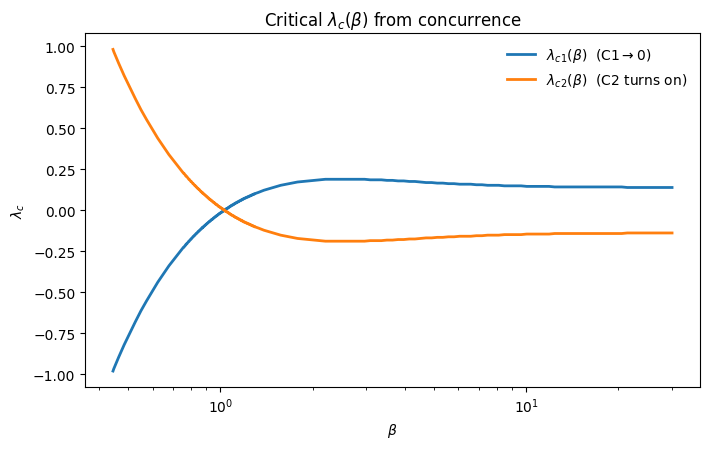

In [9]:
fig, ax, (betas, lamc1, lamc2) = make_figure_lambda_critical_vs_beta(
    eps=1e-10,
    betas=betas,
    ks=KS,
    savepath=f"{FIG_DIR}/fig_7_lambda_critical_vs_beta.pdf",
    save_csv_path=f"{FIG_DIR}/lambda_critical_vs_beta.csv",
    print_values=True,
    show=True,
)

Saved Bell critical data to: figures_periodic_chain/lambda_critical_bell_vs_beta.csv


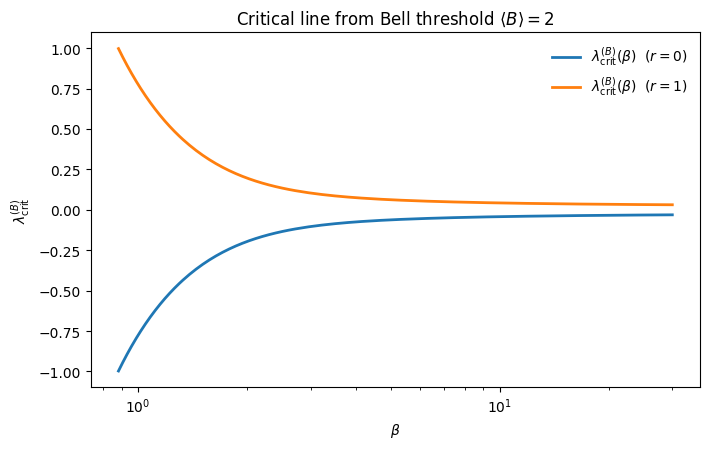

(<Figure size 720x460 with 1 Axes>,
 <Axes: title={'center': 'Critical line from Bell threshold $\\langle B\\rangle=2$'}, xlabel='$\\beta$', ylabel='$\\lambda^{(B)}_{\\mathrm{crit}}$'>,
 (array([ 0.2       ,  0.20860104,  0.21757198,  0.22692871,  0.23668783,
          0.24686664,  0.25748319,  0.26855631,  0.28010563,  0.29215164,
          0.30471568,  0.31782005,  0.33148797,  0.34574368,  0.36061246,
          0.37612068,  0.39229583,  0.4091666 ,  0.4267629 ,  0.44511593,
          0.44766611,  0.46425824,  0.48422377,  0.50504791,  0.52676761,
          0.54942137,  0.57304935,  0.59769346,  0.6233974 ,  0.65020674,
          0.67816902,  0.70733383,  0.73775288,  0.75      ,  0.75230821,
          0.75462352,  0.75694596,  0.75927554,  0.7616123 ,  0.76395624,
          0.7663074 ,  0.7686658 ,  0.7694801 ,  0.77103145,  0.77340439,
          0.77578463,  0.77817219,  0.7805671 ,  0.78296938,  0.78537906,
          0.78779615,  0.79022068,  0.79265267,  0.79509214,  0.79753913,


In [15]:
make_figure_lambda_critical_bell_vs_beta(
    betas=betas,
    save_csv_path=f"{FIG_DIR}/lambda_critical_bell_vs_beta.csv",
)

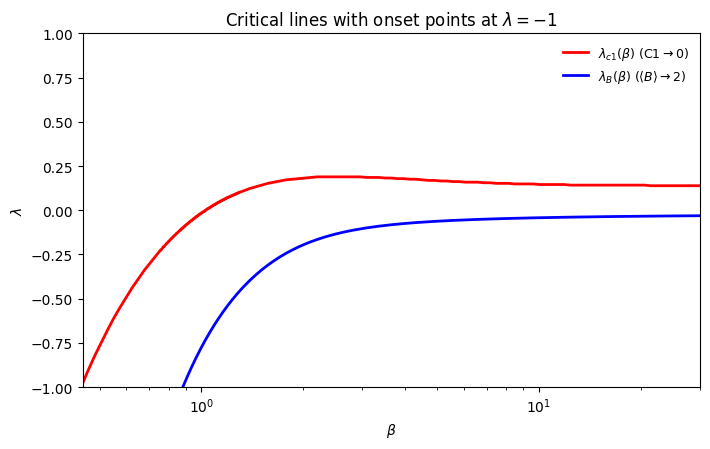

(<Figure size 720x460 with 1 Axes>,
 <Axes: title={'center': 'Critical lines with onset points at $\\lambda=-1$'}, xlabel='$\\beta$', ylabel='$\\lambda$'>)

In [16]:
plot_lambda_critical_with_onsets(
    csv_conc_path="figures_periodic_chain/lambda_critical_vs_beta.csv",
    csv_bell_path="figures_periodic_chain/lambda_critical_bell_vs_beta.csv",
    lam_onset=-1.0,
    out_pdf_path="figures_periodic_chain/fig_lambda_crit_with_onsets.pdf",
    show=True,
)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_entanglement_phase_diagram_like_curves(
    csv_conc_path,
    csv_bell_path,
    lam_min=-1.0,
    lam_max=1.0,
    out_pdf_path=None,
    show=True,
    title=r"Entanglement Phase Diagram ($r=0$)",
):
    # --- load concurrence CSV
    conc = np.genfromtxt(csv_conc_path, delimiter=",", names=True)
    beta_c = conc["beta"].astype(float)
    lam_c1 = conc["lambda_c1"].astype(float)

    mc = np.isfinite(beta_c) & np.isfinite(lam_c1)
    beta_c, lam_c1 = beta_c[mc], lam_c1[mc]
    oc = np.argsort(beta_c)
    beta_c, lam_c1 = beta_c[oc], lam_c1[oc]

    # --- load bell CSV
    bell = np.genfromtxt(csv_bell_path, delimiter=",", names=True)
    beta_b = bell["beta"].astype(float)
    lam_B0 = bell["lambda_B_r0"].astype(float)

    mb = np.isfinite(beta_b) & np.isfinite(lam_B0)
    beta_b, lam_B0 = beta_b[mb], lam_B0[mb]
    ob = np.argsort(beta_b)
    beta_b, lam_B0 = beta_b[ob], lam_B0[ob]

    # --- choose a common beta grid for plotting
    # Use concurrence betas as master grid (dense) and interpolate Bell onto it.
    beta = beta_c.copy()
    lc1  = lam_c1.copy()

    # Bell is only defined on [min(beta_b), max(beta_b)] after interpolation;
    # outside we set NaN so we DO NOT fill blue there.
    lB = np.full_like(beta, np.nan, dtype=float)
    in_range = (beta >= beta_b.min()) & (beta <= beta_b.max())
    lB[in_range] = np.interp(beta[in_range], beta_b, lam_B0)

    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    # --- Grey (separable) above lc1: always fill
    ax.fill_between(beta, lc1, lam_max, color="lightgrey", alpha=0.5)

    # --- Yellow (entangled but local):
    # where Bell is NOT defined: [lam_min, lc1]
    m_noB = np.isnan(lB)
    ax.fill_between(beta[m_noB], lam_min, lc1[m_noB], color="khaki", alpha=0.7)

    # where Bell IS defined: [lB, lc1]  (only if lc1 > lB; otherwise skip)
    m_yesB = np.isfinite(lB)
    # optional safety if curves cross numerically
    lower = np.minimum(lB[m_yesB], lc1[m_yesB])
    upper = np.maximum(lB[m_yesB], lc1[m_yesB])
    ax.fill_between(beta[m_yesB], lower, upper, color="khaki", alpha=0.7)

    # --- Blue (Bell-violating): ONLY where Bell exists -> [lam_min, lB]
    ax.fill_between(beta[m_yesB], lam_min, lB[m_yesB], color="lightblue", alpha=0.6)

    # --- Plot curves
    ax.plot(beta, lc1, color="red", lw=2, label=r"$\lambda_{c1}(\beta)$ (C1$\to0$)")
    ax.plot(beta[m_yesB], lB[m_yesB], color="blue", lw=2, label=r"$\lambda_{B}(\beta)$ ($\langle B\rangle\to2$)")

    ax.set_xscale("log")
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$\lambda$")
    ax.set_ylim(lam_min, lam_max)
    ax.set_xlim(beta.min(), beta.max())
    ax.set_title(title)
    ax.legend(frameon=False)

    plt.tight_layout()
    if out_pdf_path is not None:
        os.makedirs(os.path.dirname(out_pdf_path), exist_ok=True)
        fig.savefig(out_pdf_path, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

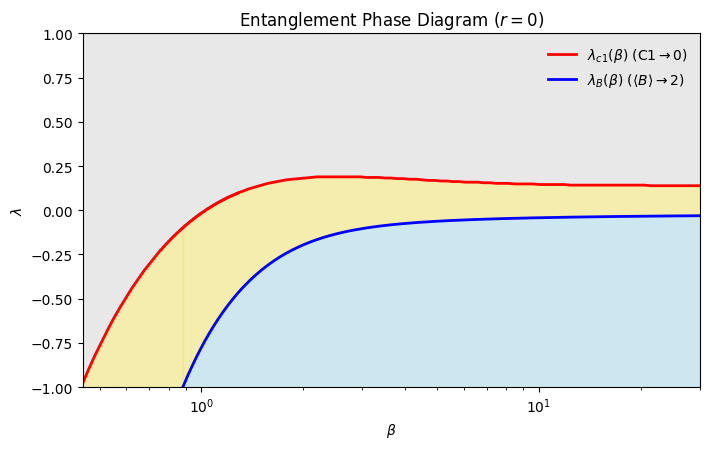

In [21]:
fig, ax = plot_entanglement_phase_diagram_like_curves(
    csv_conc_path="figures_periodic_chain/lambda_critical_vs_beta.csv",
    csv_bell_path="figures_periodic_chain/lambda_critical_bell_vs_beta.csv",
    out_pdf_path="figures_periodic_chain/fig_entanglement_phase_diagram_r0.pdf",
    show=True,
)